#Практическая работа номер 2
#тема работы майнинг данных и полиномиальная регрессия

в науке и разработке систем поддержки принятий решений (СППР)
часто требуется моделировать зависимости на основе наборов данных.
Методология (совокупность большого колва методов это подход и наличие методов для выполениня работы)
Методолгия работы с данными определяется стандартом CRISP-DM (Cross-Industry Standard Process of Data Mining)
переводится как межотрослевой стандартный проццес Майнинга данных и обьясняется как универсальный подход межотрослевой
к анализу данных. Методолгия CRISP-DM показана на рисунке 1.



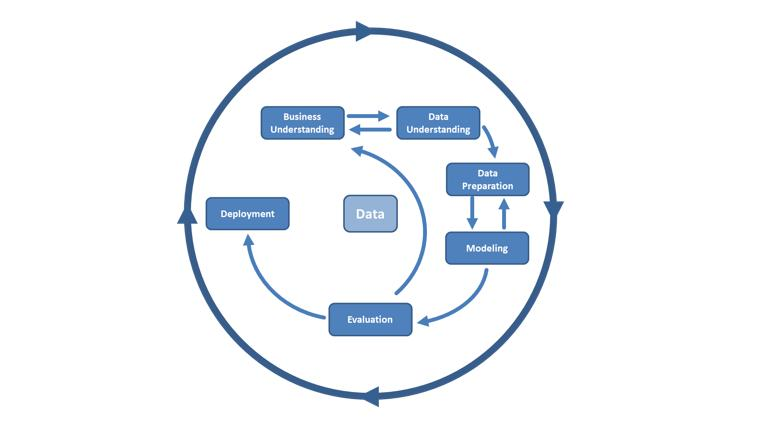


Рисунок 1 - Схема Метологий CRISP и её стадийность

CRISP-DM является адаптацией Agile-подхода к анализу данных.

In [1]:
import pandas as pd

df= pd.read_csv('Ice_cream selling data.csv')
df.head()

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


Text(0.5, 1.0, 'Фигуративное облако точек')

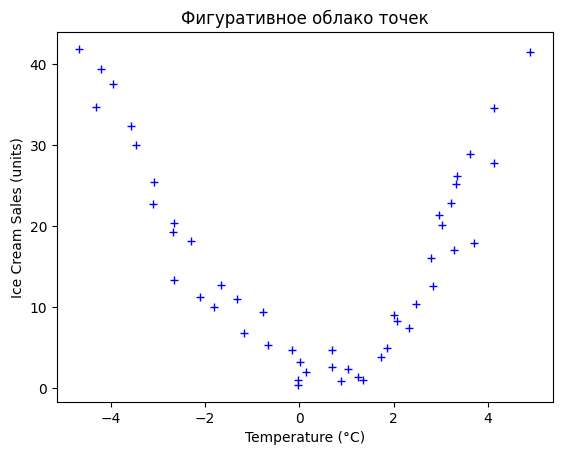

In [2]:
from matplotlib import pyplot as plt
x = list(df['Temperature (°C)'])
y = list(df['Ice Cream Sales (units)'])

plt.plot(x,y,'b+')
plt.xlabel('Temperature (°C)')
plt.ylabel('Ice Cream Sales (units)')
plt.title('Фигуративное облако точек')

"Понимание данных" в методологий CRISP-DM включает и сопровождается следующими действиями :
<ol>
    <li>Визуализация данных</li>
    <li>Поиск "выбросов" и аномалий (используется визуализация,анализ дисперсии,IsolationForests)</li>
    <li>Предварительная обработка данных,включая масштабирование (нормализаций и стандартизаций)</li>
    

In [3]:
from sklearn.model_selection import train_test_split
X = x
y = y
X_train,X_test, y_train, y_test = train_test_split( X, y, shuffle=True, test_size=0.2, random_state=42)
print('Колво записей в наборе для обучения',len(X_train))
print('Колво записей в наборе для тестирования',len(y_test))
print(type(X))
print(type(X_train[0]))

Колво записей в наборе для обучения 39
Колво записей в наборе для тестирования 10
<class 'list'>
<class 'float'>


In [9]:
# # задача дан список произвольных чисел создать список квадратов этих чисел
# numbers = [1,2,3,4,5,6]
# squares = [i**2 for i in numbers]
# # for i in numbers:
# #     squares.append(i**2)
print(squares)

[1, 4, 9, 16, 25, 36]


[ 1.87145125 -0.70641926  2.76830583]
X[0] -4.662262677220208
f(X[0])1 46.74097975085498
f(X[0])2 46.74097975085498


<function matplotlib.pyplot.show(close=None, block=None)>

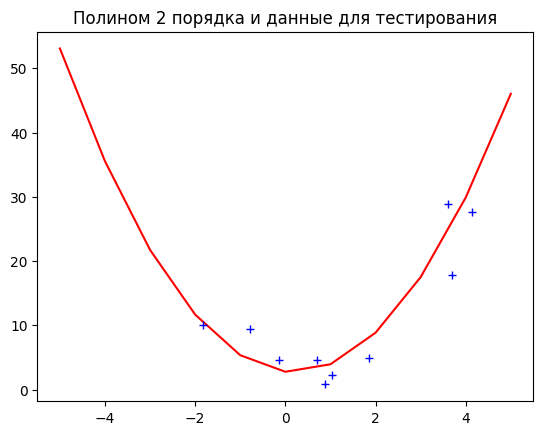

In [4]:
import numpy as np

info = """
  Для моделирования используем функцию polyfit
  из библиоткеи numpy

"""

coeff = np.polyfit(X_train,y_train,deg = 2)
print(coeff)



def model_n_order(coeff,x_in):
  out = []
  powers = list(range(0,len(coeff)))[::-1]

  for c,p in zip(coeff,powers):
    out.append(c*x_in**p)
  return sum(out)
#Модель
f_x = lambda x: coeff[0]*x**2 + coeff[1]*x + coeff[2]

X_model = list(range(-5,6))
y_model = [f_x(x)for x in X_model]

print('X[0]',X[0])
print('f(X[0])1',f_x(X[0]))
print('f(X[0])2',model_n_order(coeff,X[0]))
plt.plot(X_model,y_model,'r-')
plt.plot(X_test,y_test,'b+')
plt.title('Полином 2 порядка и данные для тестирования')
plt.show

In [19]:
print("Вычесление метрик качества обучения для полинома второго порядка")
# создаю набор y для тестовых значений X
ymodel = [model_n_order(coeff,xi) for xi in X_test]
print(ymodel)
print(y_test)

delta_m = [((ym-yt)**2)**0.5 for ym,yt in zip(ymodel,y_test)]
print(delta_m)
#mean absolute error
MAE = sum(delta_m)/len(delta_m)
print(MAE)
delta_m_rel = [100*((ym-yt)**2)**0.5/yt for ym,yt in zip(ymodel,y_test)]
print(delta_m_rel)

Вычесление метрик качества обучения для полинома второго порядка
[np.float64(10.244998524618623), np.float64(25.8280771409668), np.float64(31.824104104081513), np.float64(24.617042032254012), np.float64(4.43380256405445), np.float64(4.0078567162364465), np.float64(3.5827749143291907), np.float64(3.17865086523308), np.float64(7.869904520486553), np.float64(2.915913684753998)]
[10.012867848328883, 17.84395651991352, 27.69838334813044, 28.912187929191944, 9.392968661109096, 2.313806358173546, 0.7899736505077737, 4.625689457527259, 4.857987801146915, 4.673642540546473]
[np.float64(0.23213067628974038), np.float64(7.9841206210532825), np.float64(4.125720755951072), np.float64(4.295145896937932), np.float64(4.959166097054646), np.float64(1.6940503580629005), np.float64(2.792801263821417), np.float64(1.447038592294179), np.float64(3.011916719339639), np.float64(1.7577288557924753)]
3.229981983659728
[np.float64(2.3183235792778616), np.float64(44.744116094113735), np.float64(14.89516808290382)

In [20]:
# A/B тестирование


1488
